In [72]:
import random

import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, benchmarks

# Basics and stats

In [ ]:
if hasattr(creator, "FitnessMin"):
    del creator.FitnessMin
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

if hasattr(creator, "Individual"):
    del creator.Individual
creator.create("Individual", list, fitness=creator.FitnessMin)

In [36]:
IND_SIZE = 5

toolbox = base.Toolbox()

toolbox.register("attribute", random.random)

toolbox.register(
    "individual", tools.initRepeat, creator.Individual, toolbox.attribute, n=IND_SIZE
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(individual):
    return sum(individual),

toolbox.register("mate", tools.cxTwoPoint)

toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

toolbox.register("evaluate", evaluate)

In [53]:
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

In [59]:
def main(NGEN=40, POPSIZE=10):
    
    logbook = tools.Logbook()
    
    hof = tools.HallOfFame(1)

    pop = toolbox.population(n=POPSIZE)
    CXPB, MUTPB = 0.5, 0.2

    fitnesses = list(map(toolbox.evaluate, pop))

    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    for g in range(NGEN):
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        
        pop[:] = offspring
        
        hof.update(pop)
        stat = stats.compile(pop)
        logbook.record(gen=g, **stat)
    return pop, hof, logbook

In [68]:
pop, hof, logbook = main(100, 10)
print(f"Best={evaluate(hof[0])[0]}", str(hof[0]))
print()
for i, ind in enumerate(pop):
    print(f"Indiv[{i}]={evaluate(ind)[0]}", str(ind))

Best=-27.19842354620114 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -2.7807732989819822]

Indiv[0]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[1]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[2]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[3]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[4]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[5]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.870376056297182, -1.610764626522132, -0.8721848195155899]
Indiv[6]=-25.28983506673475 [-5.533973512399166, -6.402536052000678, -10.8703760562971

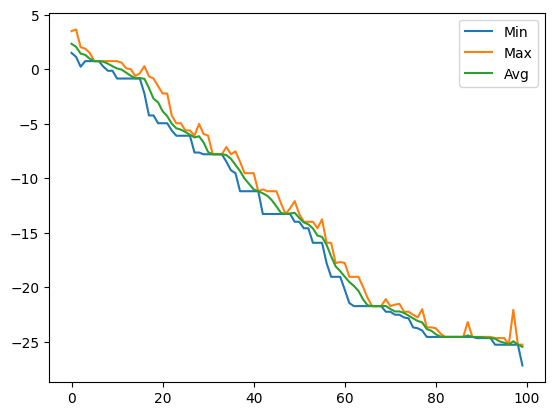

In [71]:
gen, min_v, avg_v, max_v = logbook.select("gen", "min", "avg", "max")

plt.plot(gen, min_v, label="Min")
plt.plot(gen, max_v, label="Max")
plt.plot(gen, avg_v, label="Avg")
plt.legend();

# Multi-Objective: back to single objective

In [75]:
from operator import mul


def weighted_sum(fit, w):
    return sum(map(mul, fit, w))


def tchebycheff(fit, w, ref_point=None):
    assert ref_point is not None, "define reference point"
    v = [abs(fit[i] - ref_point[i]) for i in range(len(fit))]
    w = np.abs(w)
    return -max(map(mul, v, w))


def main(
    NGEN=40,
    POPSIZE=10,
    evaluate=benchmarks.zdt1,
    evaluate_args=None,
    w=(-1.0, -1.0),
    scalarizing=weighted_sum,
    scalarizing_args=None,
):
    MIN_V = 0.0
    MAX_V = 1.0

    if hasattr(creator, "Fitness"):
        del creator.Fitness
    creator.create("Fitness", base.Fitness, weights=(1.0))

    if hasattr(creator, "Individual"):
        del creator.Individual

    creator.create("Individual", list, fitness=creator.Fitness)

    IND_SIZE = 30

    toolbox = base.Toolbox()

    toolbox.register("attribute", random.uniform, MIN_V, MAX_V)

    toolbox.register(
        "individual",
        tools.initRepeat,
        creator.Individual,
        toolbox.attribute,
        n=IND_SIZE,
    )

    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register(
        "mate", tools.cxSimulatedBinaryBounded, eta=15, low=MIN_V, up=MAX_V
    )

    toolbox.register("mutate", tools.mutPolynomialBounded, eta=15, low=MIN_V, up=MAX_V)

    toolbox.register("select", tools.selTournament, tournsize=3)

    if evaluate_args is None:
        toolbox.register("evaluate", evaluate)
    else:
        toolbox.register("evaluate", evaluate, **evaluate_args)

    stats = tools.Statistics(key=lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    logbook = tools.logbook()

    hof = tools.HallOfFame(1)

    pop = toolbox.population(n=POPSIZE)
    CXPB, MUTPB = 0.5, 0.2

    fitnesses = list(map(toolbox.evaluate, pop))

    for ind, fit in zip(pop, fitnesses):
        if scalarizing_args is None:
            ind.fitness.values = (scalarizing(fit, w),)
        else:
            ind.fitness.values = (scalarizing(fit, w, **scalarizing_args),)

    for g in range(NGEN):
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            if scalarizing_args is None:
                ind.fitness.values = (scalarizing(fit, w),)
            else:
                ind.fitness.values = (scalarizing(fit, w, **scalarizing_args),)
        
        pop[:] = offspring
        
        hof.update(pop)
        stat = stats.compile(pop)
        logbook.record(gen=g, **stat)
    
    return pop, hof, logbook

In [ ]:
def get_fitness_values(pop, evaluate, evaluate_args):
    x=[]
    y=[]
    